In [1]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
# Set seeds
def set_seeds(seed: int=42):
    """Sets random sets for torch operations.

    Args:
        seed (int, optional): Random seed to set. Defaults to 42.
    """
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)

set_seeds()

In [4]:
# 0. Import necessary modules
from transformers import AutoModelForImageClassification, AutoTokenizer

# 1. Get pretrained weights for ViT-Base from Hugging Face
pretrained_vit_weights = "google/vit-base-patch32-384"

# 2. Setup a ViT model instance with pretrained weights from Hugging Face
pretrained_vit = AutoModelForImageClassification.from_pretrained(pretrained_vit_weights).to(device)

# 3. Freeze the base parameters
for parameter in pretrained_vit.base_model.parameters():
    parameter.requires_grad = False

# 4. Change the number of output classes
class_names = ['mutu1', 'mutu2', 'mutu3', 'mutu4', 'mutu5', 'mutu6']
pretrained_vit.classifier = nn.Linear(in_features=768, out_features=len(class_names)).to(device)

# Set the model to evaluation mode
pretrained_vit.eval()

# 5. Define the transforms for your dataset
transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

In [5]:
!pip install torchinfo

In [6]:

from torchinfo import summary

# Print a summary using torchinfo (uncomment for actual output)
summary(model=pretrained_vit,
        input_size=(32, 3, 384, 384), # (batch_size, color_channels, height, width)
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                                Input Shape          Output Shape         Param #              Trainable
ViTForImageClassification (ViTForImageClassification)                  [32, 3, 384, 384]    [32, 6]              --                   Partial
├─ViTModel (vit)                                                       [32, 3, 384, 384]    [32, 145, 768]       --                   False
│    └─ViTEmbeddings (embeddings)                                      [32, 3, 384, 384]    [32, 145, 768]       112,128              False
│    │    └─ViTPatchEmbeddings (patch_embeddings)                      [32, 3, 384, 384]    [32, 144, 768]       (2,360,064)          False
│    │    └─Dropout (dropout)                                          [32, 145, 768]       [32, 145, 768]       --                   --
│    └─ViTEncoder (encoder)                                            [32, 145, 768]       [32, 145, 768]       --                   False
│    │    └─Modul

#### Notice how only the output layer is trainable, where as, all of the rest of the layers are untrainable (frozen).

In [7]:
# Setup directory paths to train and test images
train_dir = '/kaggle/input/arabica-beans/arabica_beans/50-50/train'
test_dir = '/kaggle/input/arabica-beans/arabica_beans/50-50/test'

Remember, if you're going to use a pretrained model, it's generally important to ensure your own custom data is transformed/formatted in the same way the data the original model was trained on.

## And now we've got transforms ready, we can turn our images into DataLoaders using the create_dataloaders()

In [8]:
import os

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

NUM_WORKERS = os.cpu_count()

def create_dataloaders(train_dir, test_dir, transform, batch_size=10):
    train_data = ImageFolder(train_dir, transform=transform)
    test_data = ImageFolder(test_dir, transform=transform)
    class_names = train_data.classes
    train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=os.cpu_count())
    test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=os.cpu_count())
    return train_dataloader, test_dataloader, class_names

train_dataloader_pretrained, test_dataloader_pretrained, class_names = create_dataloaders(train_dir=train_dir,
                                                                                                     test_dir=test_dir,
                                                                                                     transform=transform,
                                                                                                     batch_size=10) # Could increase if we had more samples, such as here: https://arxiv.org/abs/2205.01580 (there are other improvements there too...)
 

In [9]:
# 7. Set the device to GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 8. Define your model and loss function
model = pretrained_vit
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# 9. Set the number of epochs
epochs = 50

# 10. Lists to store training and testing losses and accuracies
train_loss_history = []
train_acc_history = []
test_loss_history = []
test_acc_history = []

# 11. Training loop
for epoch in range(epochs):
    # Set model to train mode
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    # Iterate over train_dataloader
    for i, (inputs, labels) in enumerate(train_dataloader_pretrained):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(inputs)

        # Extract logits from outputs
        logits = outputs.logits

        # Calculate loss
        loss = loss_fn(logits, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Store training loss and accuracy
        train_loss += loss.item()
        train_total += labels.size(0)
        train_correct += (logits.argmax(dim=1) == labels).sum().item()

    # Store training loss and accuracy in history lists
    train_loss_history.append(train_loss / len(train_dataloader_pretrained))
    train_acc_history.append(train_correct / train_total)

    # Set model to evaluation mode
    model.eval()
    test_loss = 0
    test_correct = 0
    test_total = 0

    # Iterate over test_dataloader
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_dataloader_pretrained):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)

            # Extract logits from outputs
            logits = outputs.logits

            # Calculate loss
            loss = loss_fn(logits, labels)

            # Store testing loss and accuracy
            test_loss += loss.item()
            test_total += labels.size(0)
            test_correct += (logits.argmax(dim=1) == labels).sum().item()

    # Store testing loss and accuracy in history lists
    test_loss_history.append(test_loss / len(test_dataloader_pretrained))
    test_acc_history.append(test_correct / test_total)

    # Print current epoch, training loss, testing loss, training accuracy, and testing accuracy
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {train_loss / len(train_dataloader_pretrained):.4f}, Test Loss: {test_loss / len(test_dataloader_pretrained):.4f}, Train Acc: {train_correct / train_total * 100:.2f}%, Test Acc: {test_correct / test_total * 100:.2f}%")

Epoch 1/50, Loss: 1.6945, Test Loss: 1.5743, Train Acc: 29.00%, Test Acc: 38.33%
Epoch 2/50, Loss: 1.5031, Test Loss: 1.4210, Train Acc: 46.50%, Test Acc: 53.83%
Epoch 3/50, Loss: 1.3787, Test Loss: 1.3217, Train Acc: 50.83%, Test Acc: 59.33%
Epoch 4/50, Loss: 1.2933, Test Loss: 1.2466, Train Acc: 51.33%, Test Acc: 57.83%
Epoch 5/50, Loss: 1.2170, Test Loss: 1.1848, Train Acc: 57.50%, Test Acc: 60.17%
Epoch 6/50, Loss: 1.1581, Test Loss: 1.1381, Train Acc: 59.33%, Test Acc: 58.33%
Epoch 7/50, Loss: 1.1149, Test Loss: 1.0939, Train Acc: 61.00%, Test Acc: 63.50%
Epoch 8/50, Loss: 1.0792, Test Loss: 1.0592, Train Acc: 61.17%, Test Acc: 62.33%
Epoch 9/50, Loss: 1.0475, Test Loss: 1.0300, Train Acc: 63.50%, Test Acc: 66.00%
Epoch 10/50, Loss: 1.0175, Test Loss: 1.0022, Train Acc: 64.83%, Test Acc: 66.67%
Epoch 11/50, Loss: 0.9870, Test Loss: 0.9807, Train Acc: 66.50%, Test Acc: 69.00%
Epoch 12/50, Loss: 0.9697, Test Loss: 0.9689, Train Acc: 66.17%, Test Acc: 59.50%
Epoch 13/50, Loss: 0.9413

pretrained ViT performed far better than our custom ViT model trained from scratch (in the same amount of time).


In [10]:
# Save the model instance
torch.save(pretrained_vit.state_dict(), 'vit-hgfc-32(5050).pth')

In [11]:
# Excel Record

import pandas as pd
from pandas import ExcelWriter

data = {
    'Train Loss': train_loss_history,
    'Train Acc': train_acc_history,
    'Test Loss': test_loss_history,
    'Test Acc': test_acc_history
}

df = pd.DataFrame(data)

with ExcelWriter('vit-hgfc-32(5050).xlsx') as writer:
    df.to_excel(writer, sheet_name='All Data')
    train_loss_df = pd.DataFrame({'Epoch': train_loss_history, 'Train Loss': train_loss_history})
    train_loss_df.to_excel(writer, sheet_name='Training Loss')
    test_loss_df = pd.DataFrame({'Epoch': test_loss_history, 'Test Loss': test_loss_history})
    test_loss_df.to_excel(writer, sheet_name='Testing Loss')
    train_acc_df = pd.DataFrame({'Epoch': train_acc_history, 'Train Acc': train_acc_history})
    train_acc_df.to_excel(writer, sheet_name='Training Accuracy')
    test_acc_df = pd.DataFrame({'Epoch': test_acc_history, 'Test Acc': test_acc_history})
    test_acc_df.to_excel(writer, sheet_name='Testing Accuracy')

In [12]:
# Notepad Record
# Open a file for writing in append mode
with open('vit-hgfc-32(5050).txt', 'a') as f:
    # Write headers to the file
    f.write('Epoch,Train Loss,Train Acc,Test Loss,Test Acc\n')

    # Loop over the number of epochs
    for epoch in range(epochs):
        # Calculate training loss and accuracy
        train_loss = train_loss_history[epoch]
        train_accuracy = train_acc_history[epoch]

        # Calculate testing loss and accuracy
        test_loss = test_loss_history[epoch]
        test_accuracy = test_acc_history[epoch]

        # Write the history to the file
        f.write(f'{epoch+1},{train_loss:.4f},{train_accuracy:.4f},{test_loss:.4f},{test_accuracy:.4f}\n')

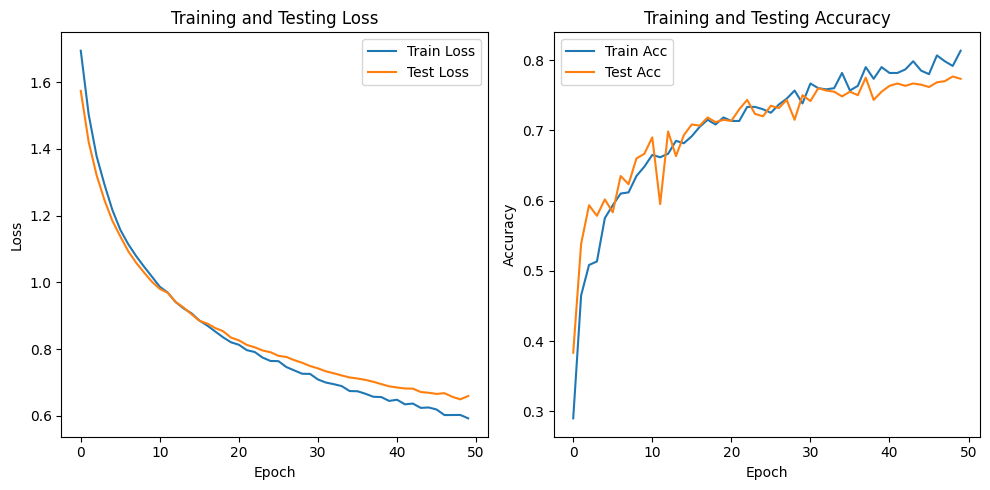

In [13]:
# Plot the training and testing loss and accuracy
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(test_loss_history, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Train Acc')
plt.plot(test_acc_history, label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracy')
plt.legend()

plt.tight_layout()

# Save the plot
plt.savefig('vit-hgfc-32(5050).png')

plt.show()

# Let's make Prediction:

In [14]:
m1 = "/kaggle/input/arabica-beans/arabica_beans/80-20/train/mutu1/1T-01.jpg"
m2 = "/kaggle/input/arabica-beans/arabica_beans/80-20/train/mutu2/2H-06.jpg"
m3 = "/kaggle/input/arabica-beans/arabica_beans/80-20/train/mutu3/3I-03.jpg"
m4 = "/kaggle/input/arabica-beans/arabica_beans/80-20/train/mutu4/4J-08.jpg"
m5 = "/kaggle/input/arabica-beans/arabica_beans/80-20/train/mutu5/5K-07.jpg"
m6 = "/kaggle/input/arabica-beans/arabica_beans/80-20/train/mutu6/6B-05.jpg"

In [15]:
def predict_image(image_path, model, class_names):
    # Load the image
    image = Image.open(image_path)

    # Define transformations to be applied to the image
    transform = transforms.Compose([
        transforms.Resize((384, 384)),  # Resize the image to the expected input size of the model
        transforms.ToTensor(),           # Convert the image to a PyTorch tensor
        transforms.Normalize(            # Normalize the image
            mean=[0.485, 0.456, 0.406],   # Mean and standard deviation values for ImageNet dataset
            std=[0.229, 0.224, 0.225]
        )
    ])

    # Apply the transformations to the image
    input_image = transform(image).unsqueeze(0)  # Add batch dimension

    # Set the device to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Move the input tensor to the device
    input_image = input_image.to(device)

    # Set the model to evaluation mode
    model.eval()

    # Perform inference
    with torch.no_grad():
        outputs = model(input_image)

    # Get the logits from the output object
    logits = outputs.logits

    # Apply softmax to get probabilities
    probabilities = torch.softmax(logits, dim=1)

    # Get the predicted class index
    predicted_class_idx = torch.argmax(probabilities).item()

    # Get the class label corresponding to the predicted index
    predicted_class_label = class_names[predicted_class_idx]

    # Get the probability score for the predicted class
    predicted_probability = probabilities[0, predicted_class_idx].item()

    # Show the image with the predicted class and probability
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Predicted class: {predicted_class_label}, Probability: {predicted_probability:.4f}")
    plt.show()

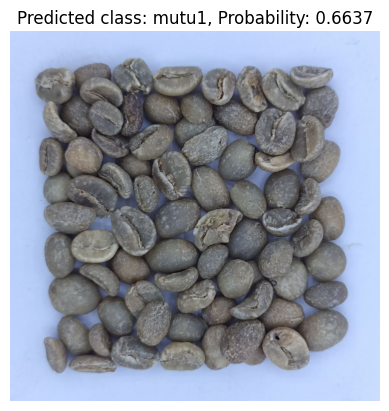

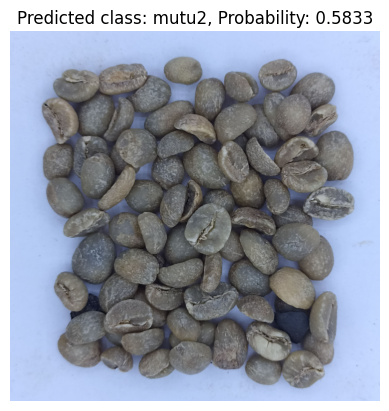

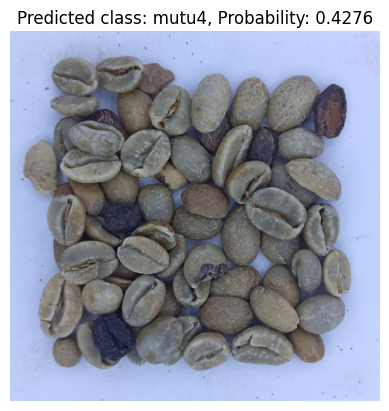

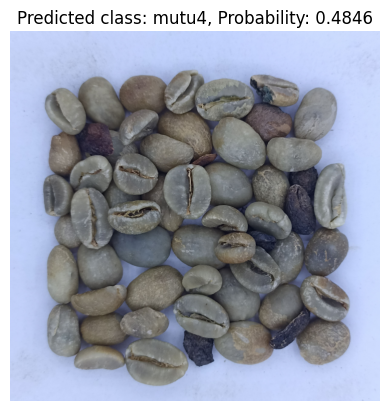

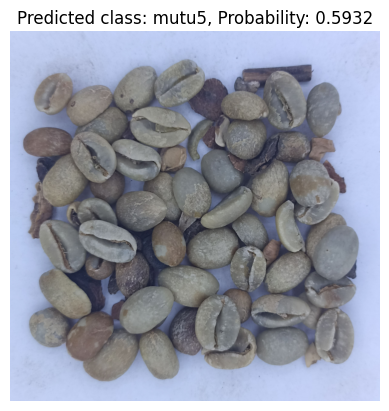

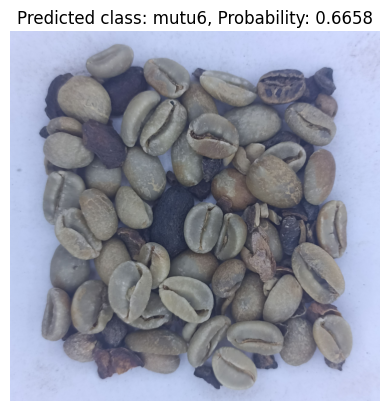

In [16]:
from PIL import Image

image_paths = [m1,m2,m3,m4,m5,m6]

# Iterate over the images and make predictions
for image_path in image_paths:
    predict_image(image_path, model, class_names)